In [1]:
import numpy as np
import time
from matplotlib import pyplot as plt

In [2]:
def save_scan(tag):
    scanner_gui.sigSaveScan.emit(('x', 'y'), scanner_gui.scan_2d_dockwidgets[('x', 'y')].scan_widget.image_widget.levels, tag, scanner_gui._save_folderpath)

In [13]:
laser_freqs = np.linspace(-16, 16, 33) * 1e3 # MHz
laser_freqs

array([-16000., -15000., -14000., -13000., -12000., -11000., -10000.,
        -9000.,  -8000.,  -7000.,  -6000.,  -5000.,  -4000.,  -3000.,
        -2000.,  -1000.,      0.,   1000.,   2000.,   3000.,   4000.,
         5000.,   6000.,   7000.,   8000.,   9000.,  10000.,  11000.,
        12000.,  13000.,  14000.,  15000.,  16000.])

In [ ]:
for laser_freq in laser_freqs:
    laser_scanner_logic.set_target_position({"a": laser_freq})
    time.sleep(5)
    scanning_probe_logic.toggle_scan(start='True', scan_axes='xy')
    while scanner_gui._scanner_settings_locked:
        time.sleep(1)
    save_scan(f"laser_freq={laser_freq*1e-3:.0}") 
    time.sleep(5)

In [ ]:
print(f"Power: {powermeter.get_process_value('Power')*1e6:.2f} uW")

In [3]:
def scan_ple(activate=True):
    ple_gui._mw.actionToggle_scan.setChecked(activate)
    ple_gui._mw.actionToggle_scan.triggered.emit()

In [4]:
def save_ple(tag=''):
    ple_gui.save_path_widget.saveTagLineEdit.setText(tag)
    ple_gui._mw.actionSave.triggered.emit()

In [14]:
pois = poi_manager_logic.poi_names[0:30]
for poi in pois:
    print(f"Measuring {poi}")
    poi_manager_logic.go_to_poi(poi)
    time.sleep(5)
    laser_scanner_logic.set_target_position({"a": -16e3})
    time.sleep(5)
    scan_ple()
    time.sleep(10)
    while laser_scanner_logic.module_state() != 'idle':
        time.sleep(1)
    time.sleep(1)
    save_ple(poi)
    time.sleep(10)
        
    

Measuring SnV_1
Measuring SnV_2
Measuring SnV_3
Measuring SnV_4
Measuring SnV_5
Measuring SnV_6
Measuring SnV_7
Measuring SnV_8
Measuring SnV_9
Measuring SnV_10
Measuring SnV_11
Measuring SnV_12
Measuring SnV_13
Measuring SnV_14
Measuring SnV_15
Measuring SnV_16
Measuring SnV_17
Measuring SnV_18
Measuring SnV_19
Measuring SnV_20
Measuring SnV_21
Measuring SnV_22
Measuring SnV_23
Measuring SnV_24
Measuring SnV_25
Measuring SnV_26
Measuring SnV_27
Measuring SnV_28
Measuring SnV_29
Measuring SnV_30


In [ ]:
dir(ple_gui)

In [6]:
laser_scanner_frequencies = np.linspace(-16, 16, 33)
laser_scanner_frequencies

array([-16., -15., -14., -13., -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,
        -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,
         6.,   7.,   8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.])

In [ ]:
ls_wavemeter_frequencies = []
for laser_freq in laser_scanner_frequencies:
    laser_scanner_logic.set_target_position({"a": laser_freq})
    time.sleep(1)
    wavemeter.read_single_point()[0][0]*1e-6
    ls_wavemeter_frequencies.append()
    
    

In [1]:
wavemeter.start_stream()

In [4]:
# wavemeter.start_stream()
wavemeter.read_single_point()[0][0]*1e-6

484013668.7763489

In [12]:
poi_manager_logic.poi_names[0:25]

['SnV_1', 'SnV_2', 'SnV_3', 'SnV_4', 'SnV_5', 'SnV_6', 'SnV_7', 'SnV_8', 'SnV_9', 'SnV_10', 'SnV_11', 'SnV_12', 'SnV_13', 'SnV_14', 'SnV_15', 'SnV_16', 'SnV_17', 'SnV_18', 'SnV_19', 'SnV_20', 'SnV_21', 'SnV_22', 'SnV_23', 'SnV_24', 'SnV_25']

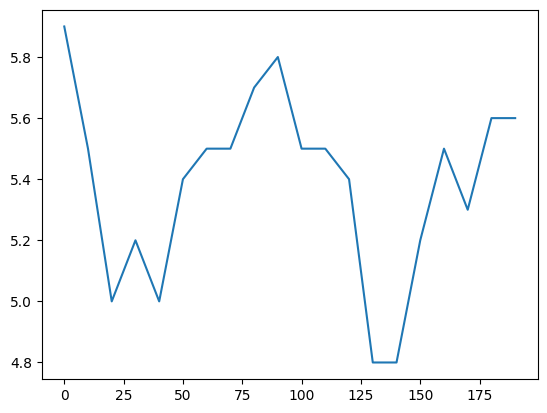

In [22]:
lambda_quater = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190] # deg
lambda_half =  [21, 19, 12, 358, 356, 328, 310, 306, 302, 110, 288, 194, 192, 196, 218, 218, 213, 208, 268, 282] # deg
counts =  [5.9, 5.5, 5.0, 5.2, 5.0, 5.4, 5.5, 5.5, 5.7, 5.8, 5.5, 5.5, 5.4, 4.8, 4.8, 5.2, 5.5, 5.3, 5.6, 5.6]


plt.plot(lambda_quater, counts)